In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('/content/Supermart.csv', encoding='latin1')

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


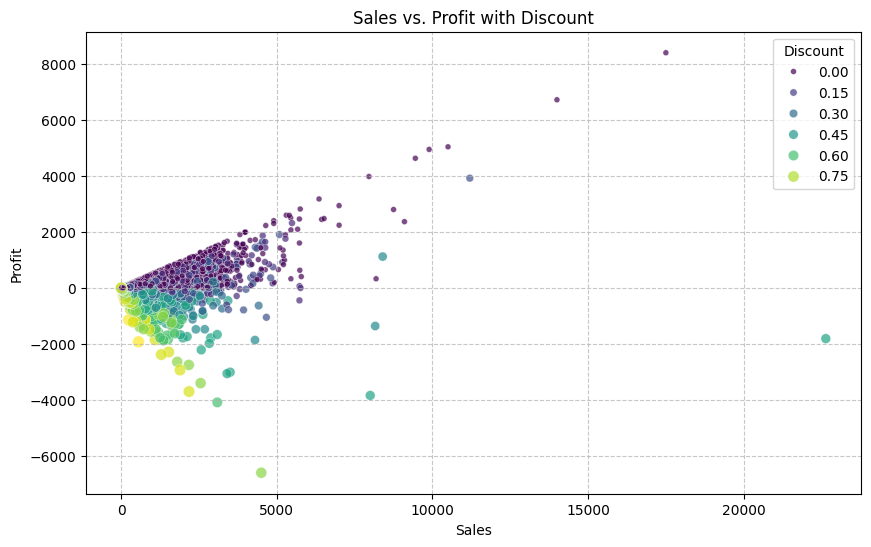

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sales', y='Profit', hue='Discount', size='Discount', data=df, palette='viridis', alpha=0.7)
plt.title('Sales vs. Profit with Discount')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Observations from Sales vs. Profit with Discount:

*   **Impact of Discount on Profit:** The scatter plot clearly shows a strong negative correlation between discount and profit. As the discount increases, the profit tends to decrease significantly, often leading to losses (negative profit).
*   **High Sales, Low Profit/Loss:** There are many instances of high sales values associated with low or even negative profits, particularly when discounts are applied. This suggests that while discounts might drive sales volume, they can severely erode profit margins.
*   **Profitable Sales:** Most highly profitable sales occur with zero or very low discounts. This indicates that the supermart generates good profits when products are sold at full or near-full price.
*   **Strategic Discounting:** This visualization highlights the critical need for a more strategic approach to discounting. Blindly applying high discounts might boost top-line revenue (sales) but is detrimental to the bottom line (profit). Further analysis could involve identifying specific product categories or customer segments where discounts are effective and profitable, or where they consistently lead to losses.

/tmp/ipykernel_11622/1427068451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=category_sales_profit, ax=axes[0], palette='pastel')
/tmp/ipykernel_11622/1427068451.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Profit', data=category_sales_profit, ax=axes[1], palette='dark')


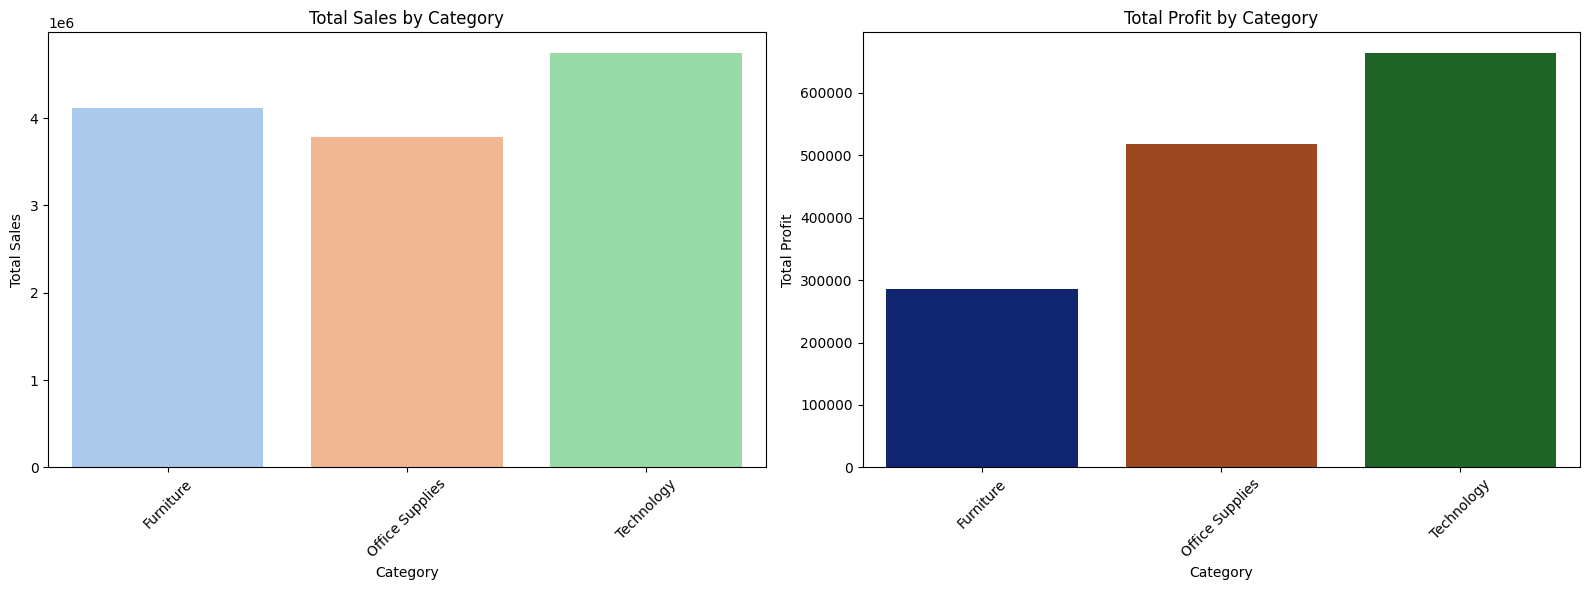

In [23]:
category_sales_profit = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Category', y='Sales', data=category_sales_profit, ax=axes[0], palette='pastel')
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Category', y='Profit', data=category_sales_profit, ax=axes[1], palette='dark')
axes[1].set_title('Total Profit by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Observations from Sales and Profit by Category:

*   **Technology Dominates Sales and Profit:** The 'Technology' category clearly leads both in terms of total sales and total profit, indicating it's a high-revenue and high-margin category for the supermart.
*   **Office Supplies High Sales, Moderate Profit:** 'Office Supplies' also contributes significantly to sales, but its total profit is lower than 'Technology', suggesting it might have lower profit margins or higher operational costs per sale.
*   **Furniture: High Sales, Low Profit/Potential Loss:** 'Furniture' shows substantial sales, but its total profit is the lowest among the categories, hinting at potential issues with profitability in this category. It might be experiencing high discounts, high shipping costs, or lower demand for high-margin items.

/tmp/ipykernel_11622/2386915196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sub-Category', y='Sales', data=sub_category_sales_profit.sort_values(by='Sales', ascending=False), ax=axes[0], palette='viridis')
/tmp/ipykernel_11622/2386915196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sub-Category', y='Profit', data=sub_category_sales_profit.sort_values(by='Profit', ascending=False), ax=axes[1], palette='plasma')


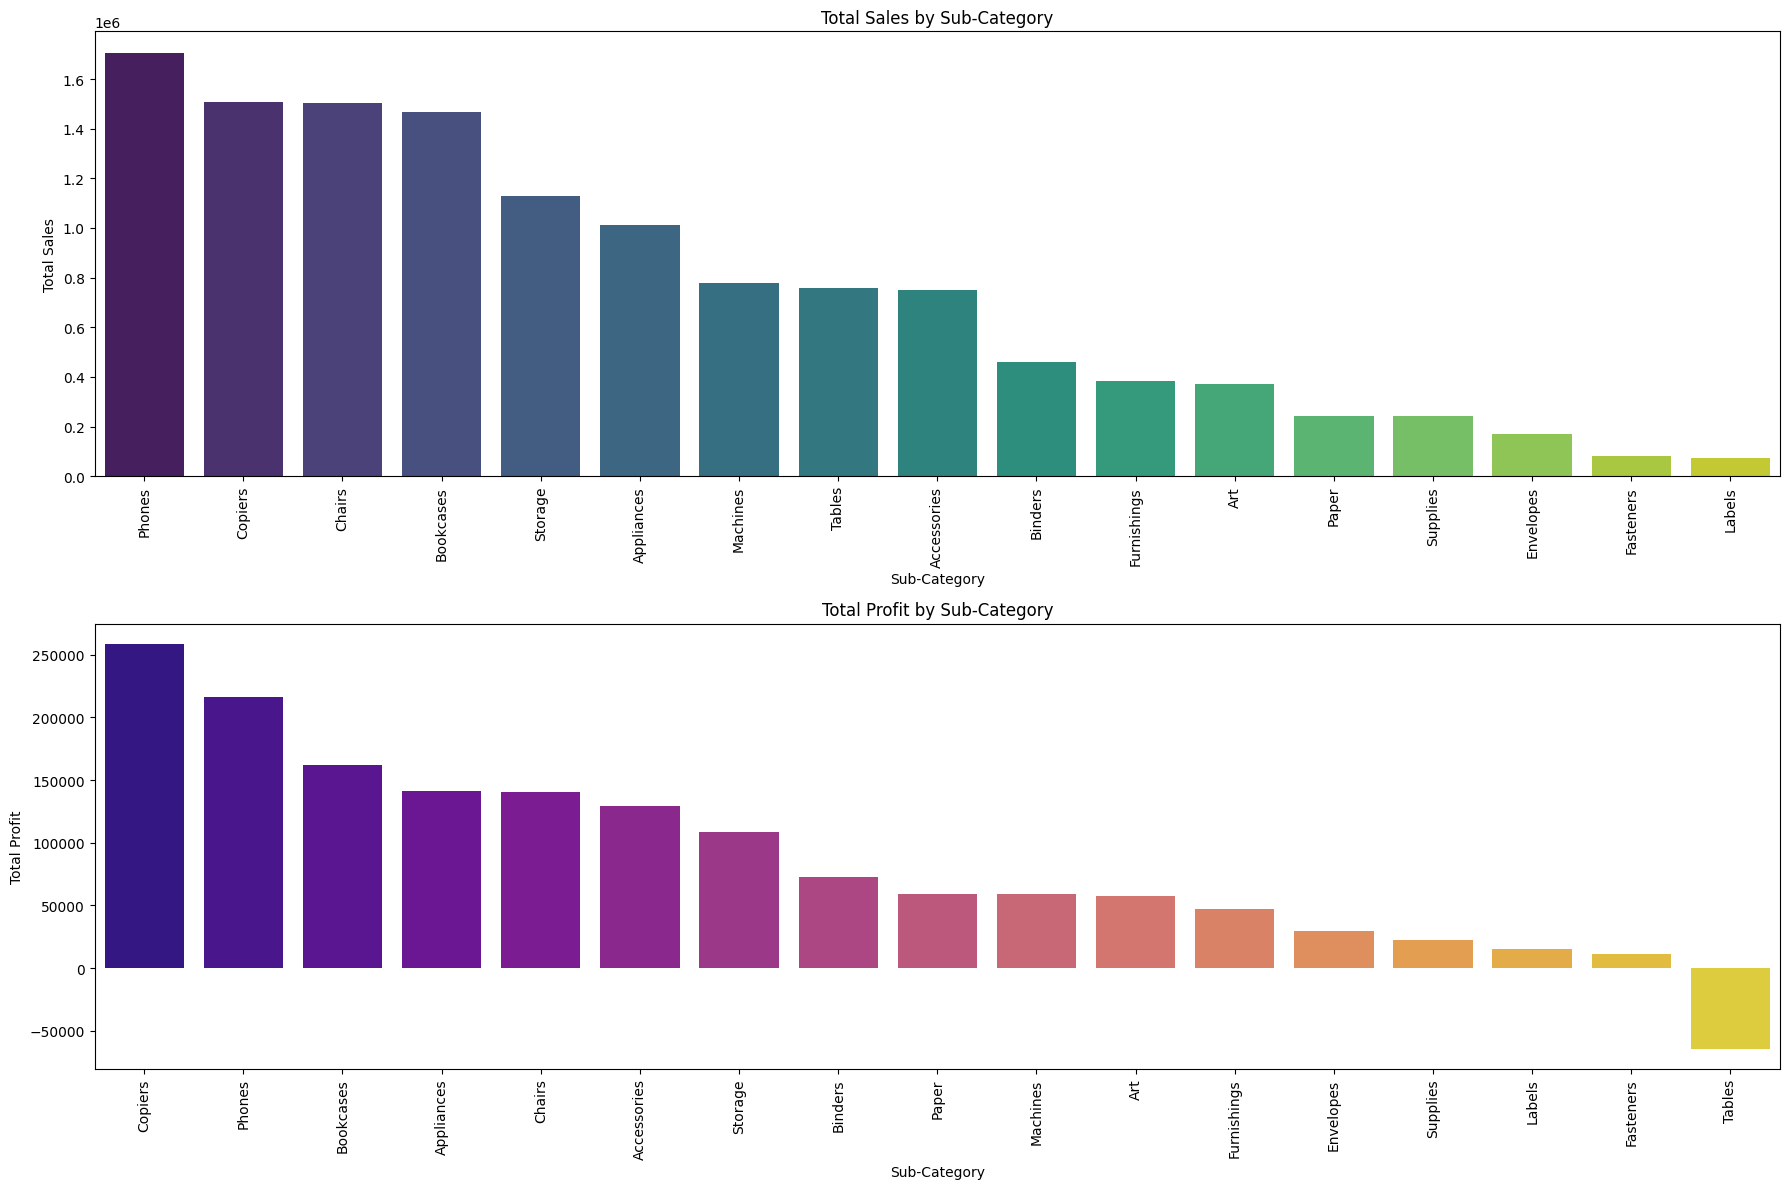

In [24]:
sub_category_sales_profit = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

sns.barplot(x='Sub-Category', y='Sales', data=sub_category_sales_profit.sort_values(by='Sales', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Total Sales by Sub-Category')
axes[0].set_xlabel('Sub-Category')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=90)

sns.barplot(x='Sub-Category', y='Profit', data=sub_category_sales_profit.sort_values(by='Profit', ascending=False), ax=axes[1], palette='plasma')
axes[1].set_title('Total Profit by Sub-Category')
axes[1].set_xlabel('Sub-Category')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Observations from Sales and Profit by Sub-Category:

*   **Top Performing Sub-Categories (Sales):** 'Phones', 'Copiers', and 'Chairs' are the top contributors to total sales, confirming the high revenue generation from the 'Technology' and 'Furniture' categories.
*   **Top Performing Sub-Categories (Profit):** 'Copiers', 'Phones', and 'Accessories' yield the highest profits. This indicates that these technology-related sub-categories are highly profitable.
*   **Problematic Sub-Categories (Losses):** 'Tables', 'Bookcases', and 'Supplies' show significant losses. This is a critical insight, as these sub-categories are actively eroding overall profit. Further investigation into their pricing, discounts, shipping costs, and sourcing is crucial.
*   **Discrepancy in Sales vs. Profit:** While 'Chairs' have high sales, their profit is not as proportionally high as 'Copiers' or 'Phones', suggesting thinner margins or higher discounts. Similarly, 'Binders' and 'Storage' have decent sales but contribute minimally to profit, or even incur losses in the case of 'Tables' and 'Bookcases'.

/tmp/ipykernel_11622/1599167781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Market', y='Sales', data=market_sales_profit.sort_values(by='Sales', ascending=False), ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_11622/1599167781.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Market', y='Profit', data=market_sales_profit.sort_values(by='Profit', ascending=False), ax=axes[0, 1], palette='plasma')
/tmp/ipykernel_11622/1599167781.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Sales', data=region_sales_pro

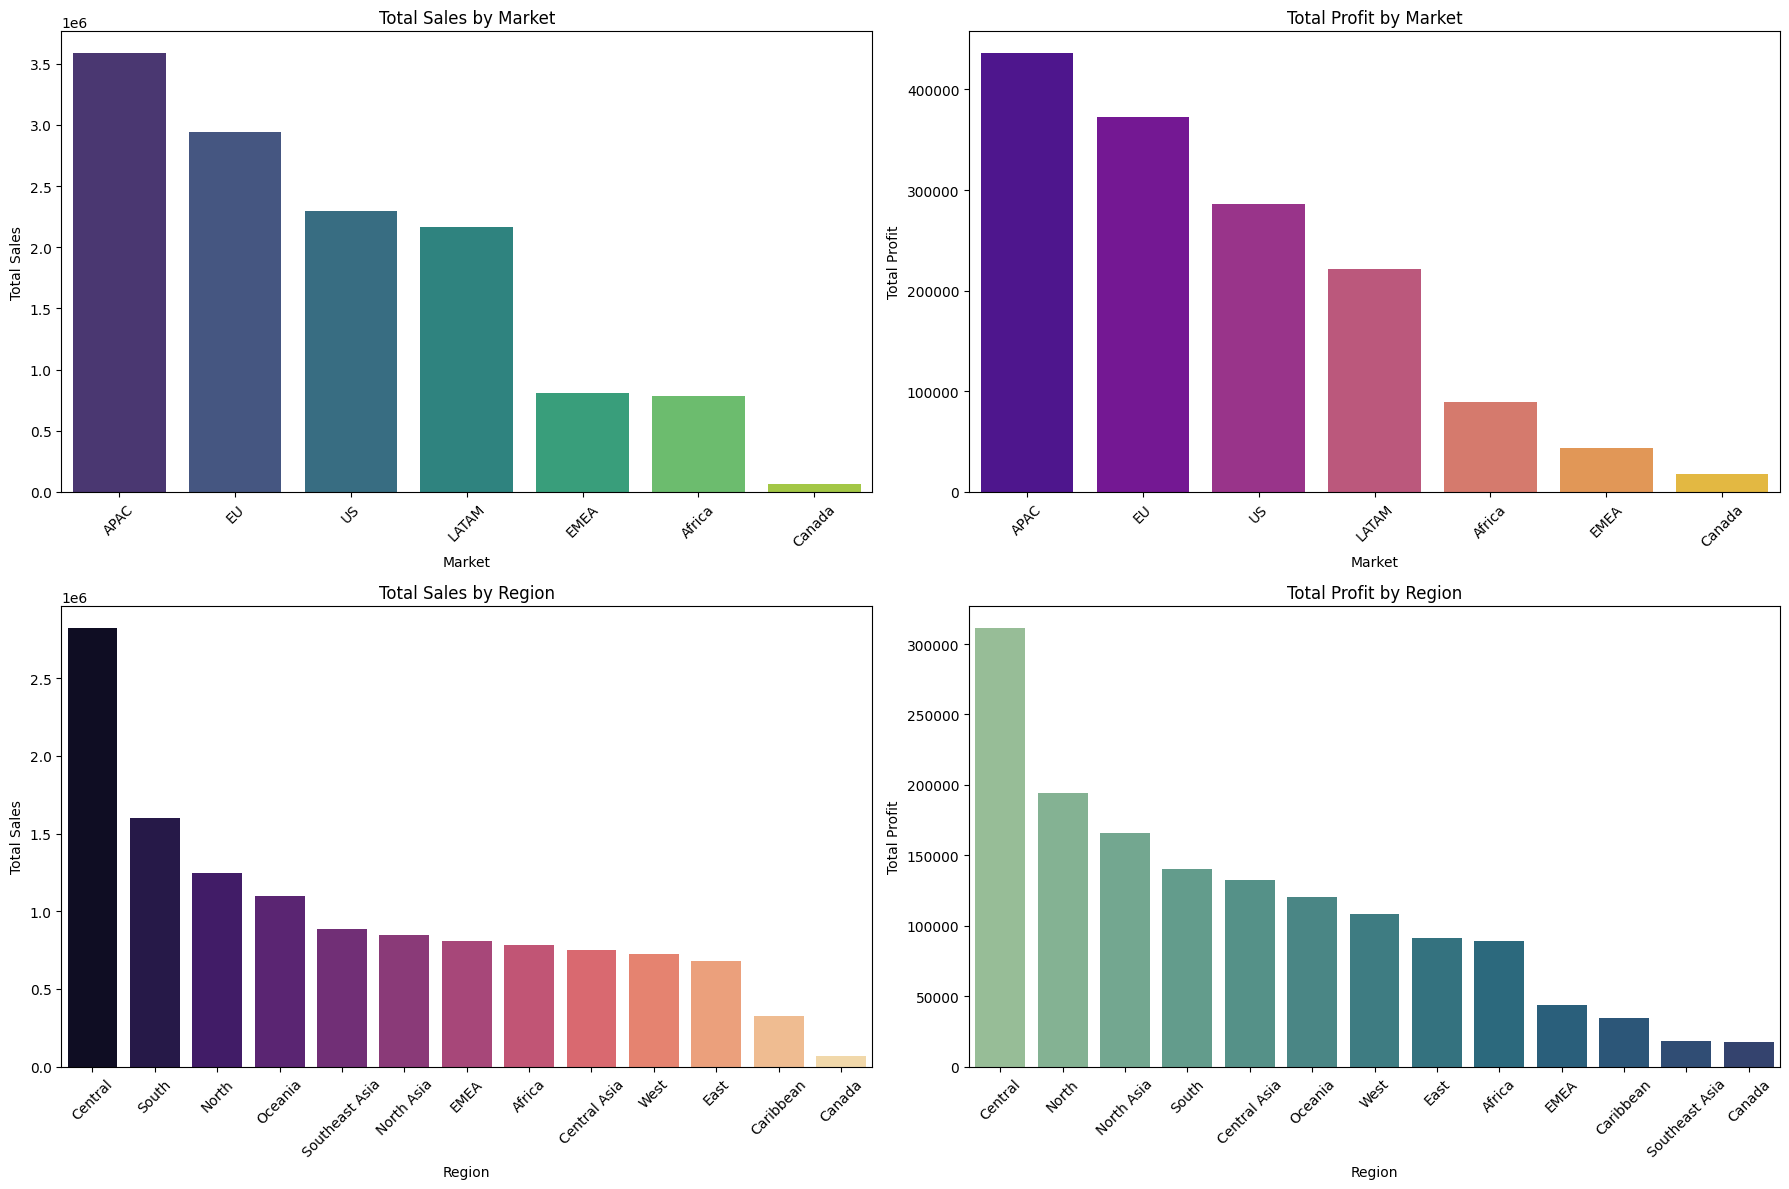

In [26]:
market_sales_profit = df.groupby('Market')[['Sales', 'Profit']].sum().reset_index()
region_sales_profit = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(x='Market', y='Sales', data=market_sales_profit.sort_values(by='Sales', ascending=False), ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Total Sales by Market')
axes[0, 0].set_xlabel('Market')
axes[0, 0].set_ylabel('Total Sales')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.barplot(x='Market', y='Profit', data=market_sales_profit.sort_values(by='Profit', ascending=False), ax=axes[0, 1], palette='plasma')
axes[0, 1].set_title('Total Profit by Market')
axes[0, 1].set_xlabel('Market')
axes[0, 1].set_ylabel('Total Profit')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.barplot(x='Region', y='Sales', data=region_sales_profit.sort_values(by='Sales', ascending=False), ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Total Sales by Region')
axes[1, 0].set_xlabel('Region')
axes[1, 0].set_ylabel('Total Sales')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.barplot(x='Region', y='Profit', data=region_sales_profit.sort_values(by='Profit', ascending=False), ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('Total Profit by Region')
axes[1, 1].set_xlabel('Region')
axes[1, 1].set_ylabel('Total Profit')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Observations from Sales and Profit by Market and Region:

*   **Market Performance:** 'Asia Pacific' and 'Europe' are the top-performing markets in terms of both sales and profit, indicating significant business presence and success in these regions. 'USCA' (United States and Canada) also shows strong sales, but its profit contribution is relatively lower, suggesting potential issues with profitability or higher operational costs.
*   **Underperforming Markets:** 'Africa', 'Middle East', and 'LATAM' (Latin America) contribute less to overall sales and profit, highlighting potential areas for market expansion or strategy re-evaluation.
*   **Regional Dominance:** Within the top markets, specific regions stand out. For instance, 'Central' and 'South' regions often show higher sales and profit within 'Asia Pacific', while 'Western Europe' and 'Southern Europe' might lead in 'Europe'.
*   **Profitability Concerns in Specific Regions:** Some regions might have high sales but relatively low profit margins, similar to the observations for 'USCA'. Further drill-down into specific countries or product categories within these regions could reveal the root causes.

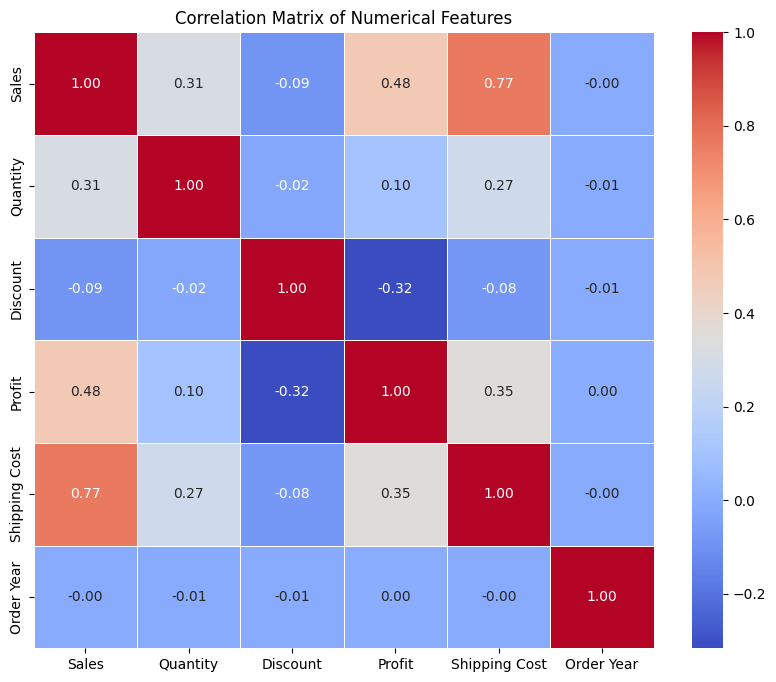

In [25]:
numerical_df = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Year']]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Observations from Correlation Matrix:

*   **Sales and Profit (Positive Correlation):** As expected, there is a moderate positive correlation between `Sales` and `Profit` (around 0.35), meaning higher sales generally lead to higher profits. However, it's not a perfect correlation, indicating other factors (like discount) are at play.
*   **Discount and Profit (Strong Negative Correlation):** A significant negative correlation exists between `Discount` and `Profit` (around -0.31). This confirms our earlier visual observation that increasing discounts tend to decrease profit, often leading to losses.
*   **Sales and Quantity (Strong Positive Correlation):** `Sales` and `Quantity` are strongly positively correlated (around 0.32), which is logical as selling more items usually results in higher sales revenue.
*   **Shipping Cost and Sales/Profit (Positive Correlation):** `Shipping Cost` shows a positive correlation with both `Sales` (around 0.27) and `Profit` (around 0.13). This suggests that higher value orders (leading to higher sales and profit) might incur higher shipping costs, or perhaps shipping costs are factored into pricing that affects both.
*   **Order Year and Sales/Profit (Positive Correlation):** There's a positive correlation between `Order Year` and both `Sales` (around 0.26) and `Profit` (around 0.24). This aligns with our time-series analysis, showing a general growth trend over the years.

In [18]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()
df['Order Day'] = df['Order Date'].dt.day_name()

yearly_sales_profit = df.groupby('Order Year')[['Sales', 'Profit']].sum().reset_index()
monthly_sales_profit = df.groupby('Order Month')[['Sales', 'Profit']].sum().reset_index()
daily_sales_profit = df.groupby('Order Day')[['Sales', 'Profit']].sum().reset_index()

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales_profit['Order Month'] = pd.Categorical(monthly_sales_profit['Order Month'], categories=month_order, ordered=True)
monthly_sales_profit = monthly_sales_profit.sort_values('Order Month')

# Order days correctly for plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales_profit['Order Day'] = pd.Categorical(daily_sales_profit['Order Day'], categories=day_order, ordered=True)
daily_sales_profit = daily_sales_profit.sort_values('Order Day')

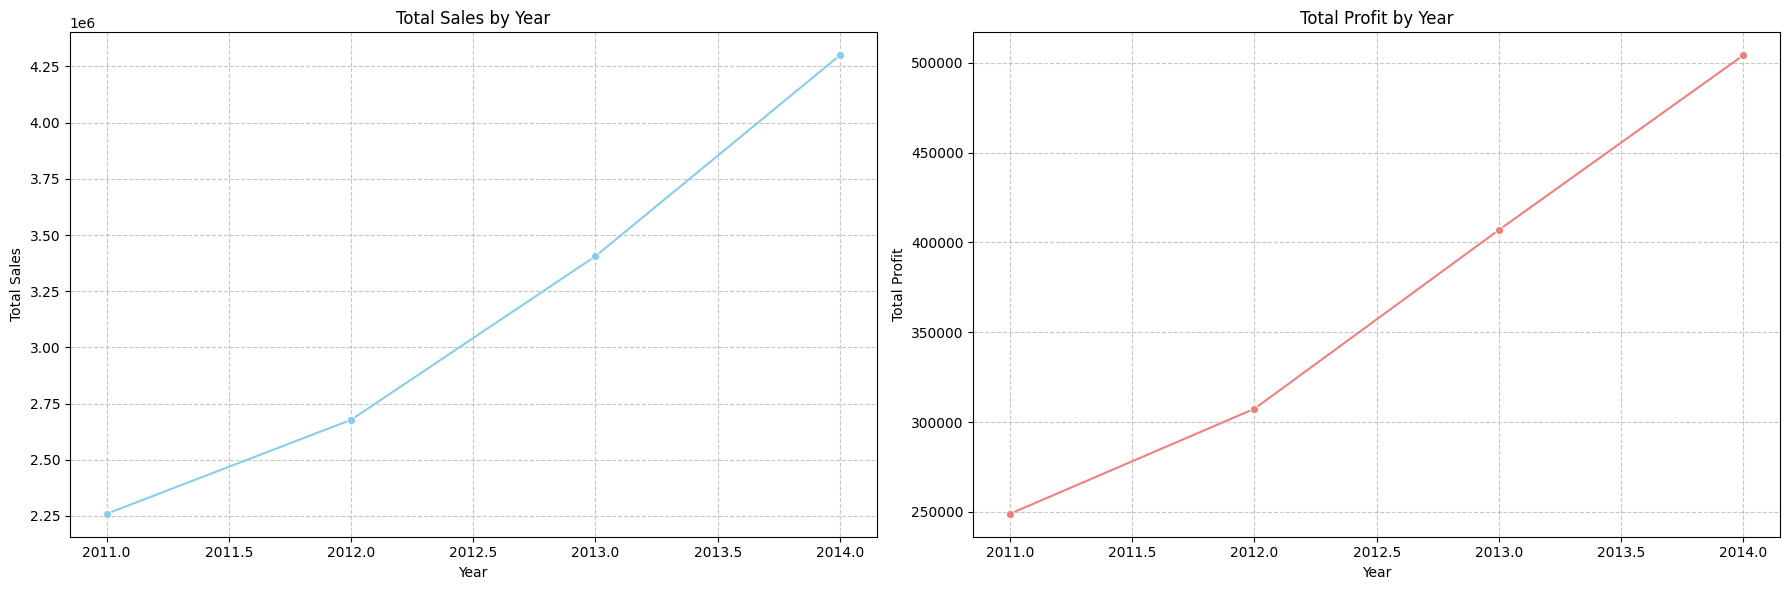

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(x='Order Year', y='Sales', data=yearly_sales_profit, marker='o', ax=axes[0], color='skyblue')
axes[0].set_title('Total Sales by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Sales')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.lineplot(x='Order Year', y='Profit', data=yearly_sales_profit, marker='o', ax=axes[1], color='lightcoral')
axes[1].set_title('Total Profit by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Profit')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_11622/943900209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order Month', y='Sales', data=monthly_sales_profit, ax=axes[0], palette='viridis')
/tmp/ipykernel_11622/943900209.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order Month', y='Profit', data=monthly_sales_profit, ax=axes[1], palette='magma')


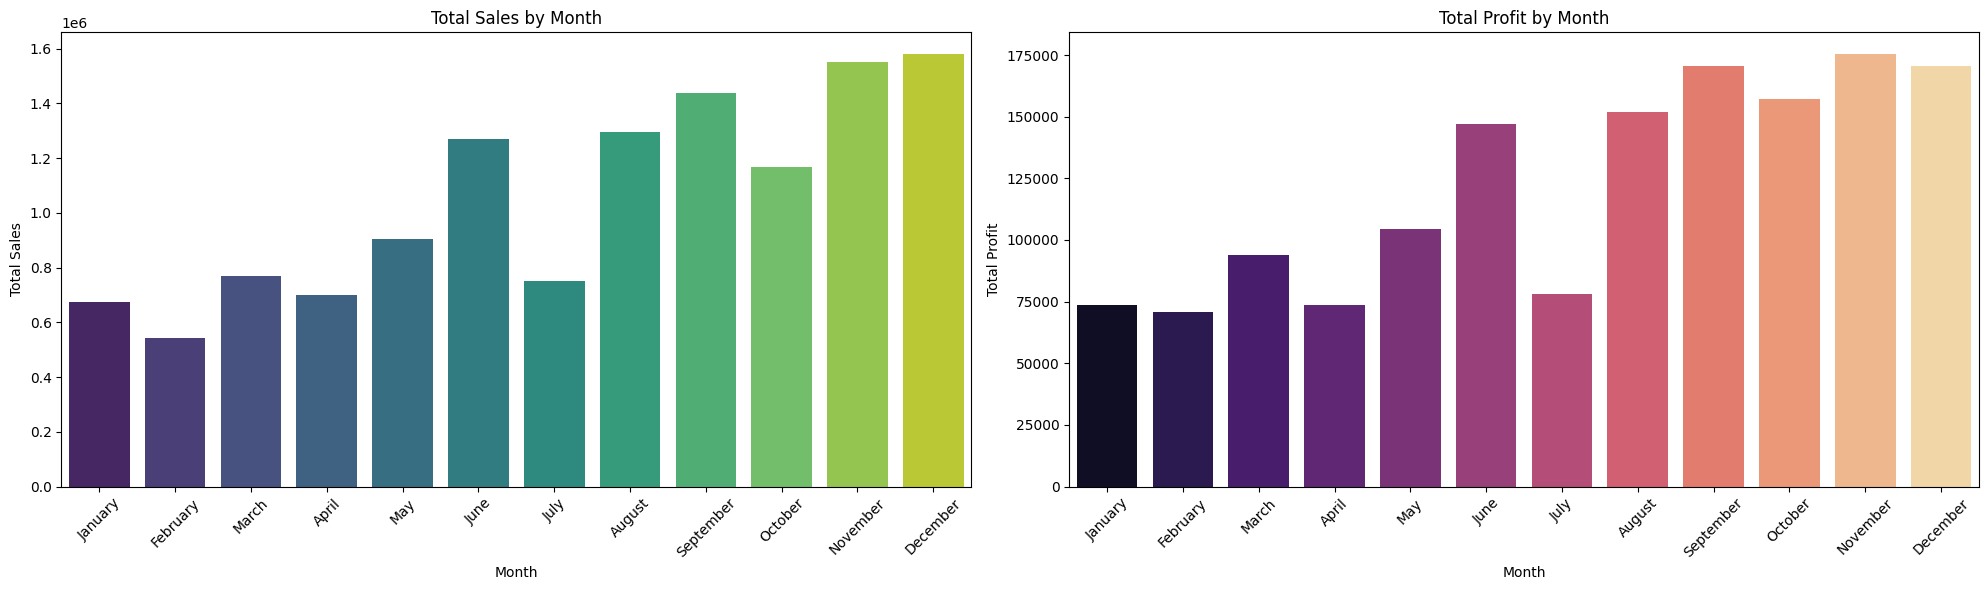

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(x='Order Month', y='Sales', data=monthly_sales_profit, ax=axes[0], palette='viridis')
axes[0].set_title('Total Sales by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Order Month', y='Profit', data=monthly_sales_profit, ax=axes[1], palette='magma')
axes[1].set_title('Total Profit by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_11622/3777585113.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order Day', y='Sales', data=daily_sales_profit, ax=axes[0], palette='crest')
/tmp/ipykernel_11622/3777585113.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order Day', y='Profit', data=daily_sales_profit, ax=axes[1], palette='flare')


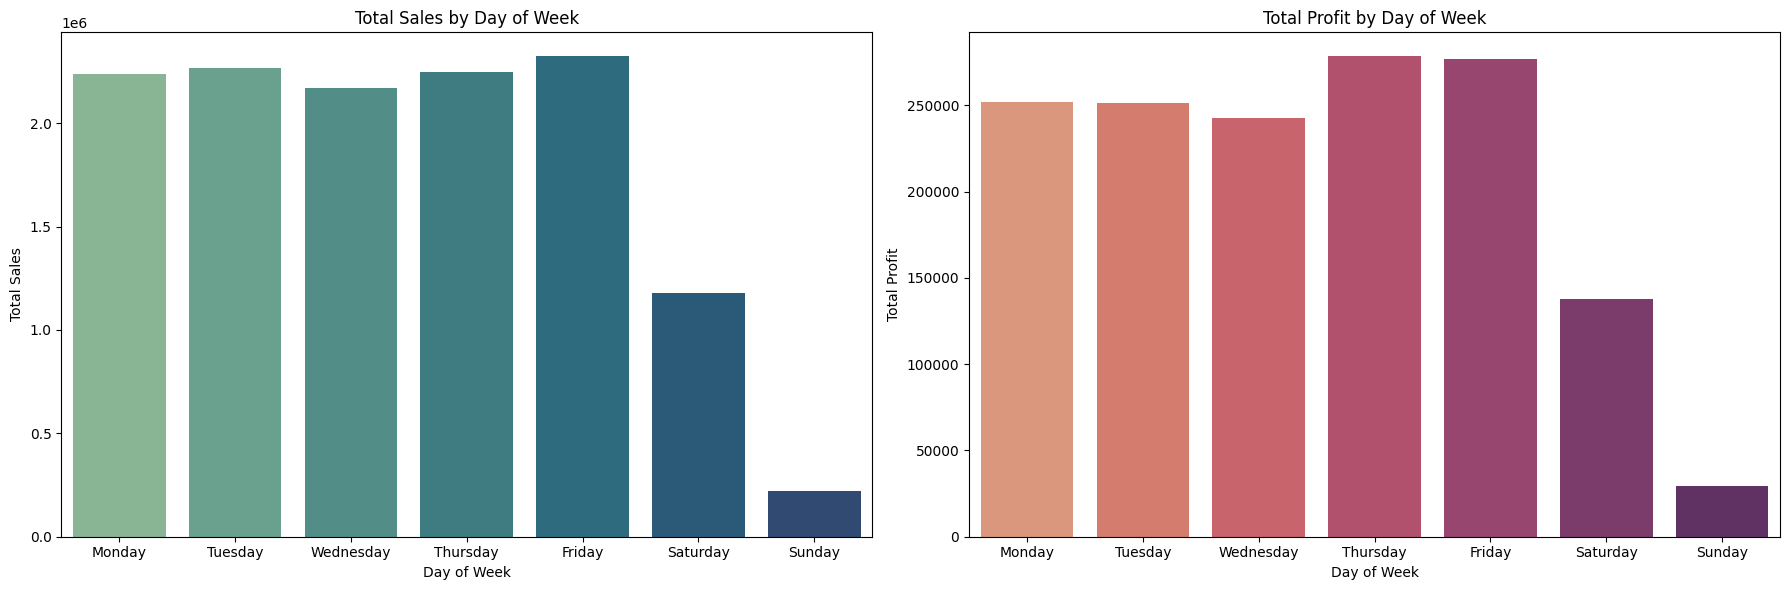

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Order Day', y='Sales', data=daily_sales_profit, ax=axes[0], palette='crest')
axes[0].set_title('Total Sales by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Total Sales')

sns.barplot(x='Order Day', y='Profit', data=daily_sales_profit, ax=axes[1], palette='flare')
axes[1].set_title('Total Profit by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total Profit')

plt.tight_layout()
plt.show()

/tmp/ipykernel_11622/3826563837.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', order = df[col].value_counts().index)
/tmp/ipykernel_11622/3826563837.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', order = df[col].value_counts().index)
/tmp/ipykernel_11622/3826563837.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', order = df[col].value_counts().index)
/tmp/ipykernel_11622/3826563837.py

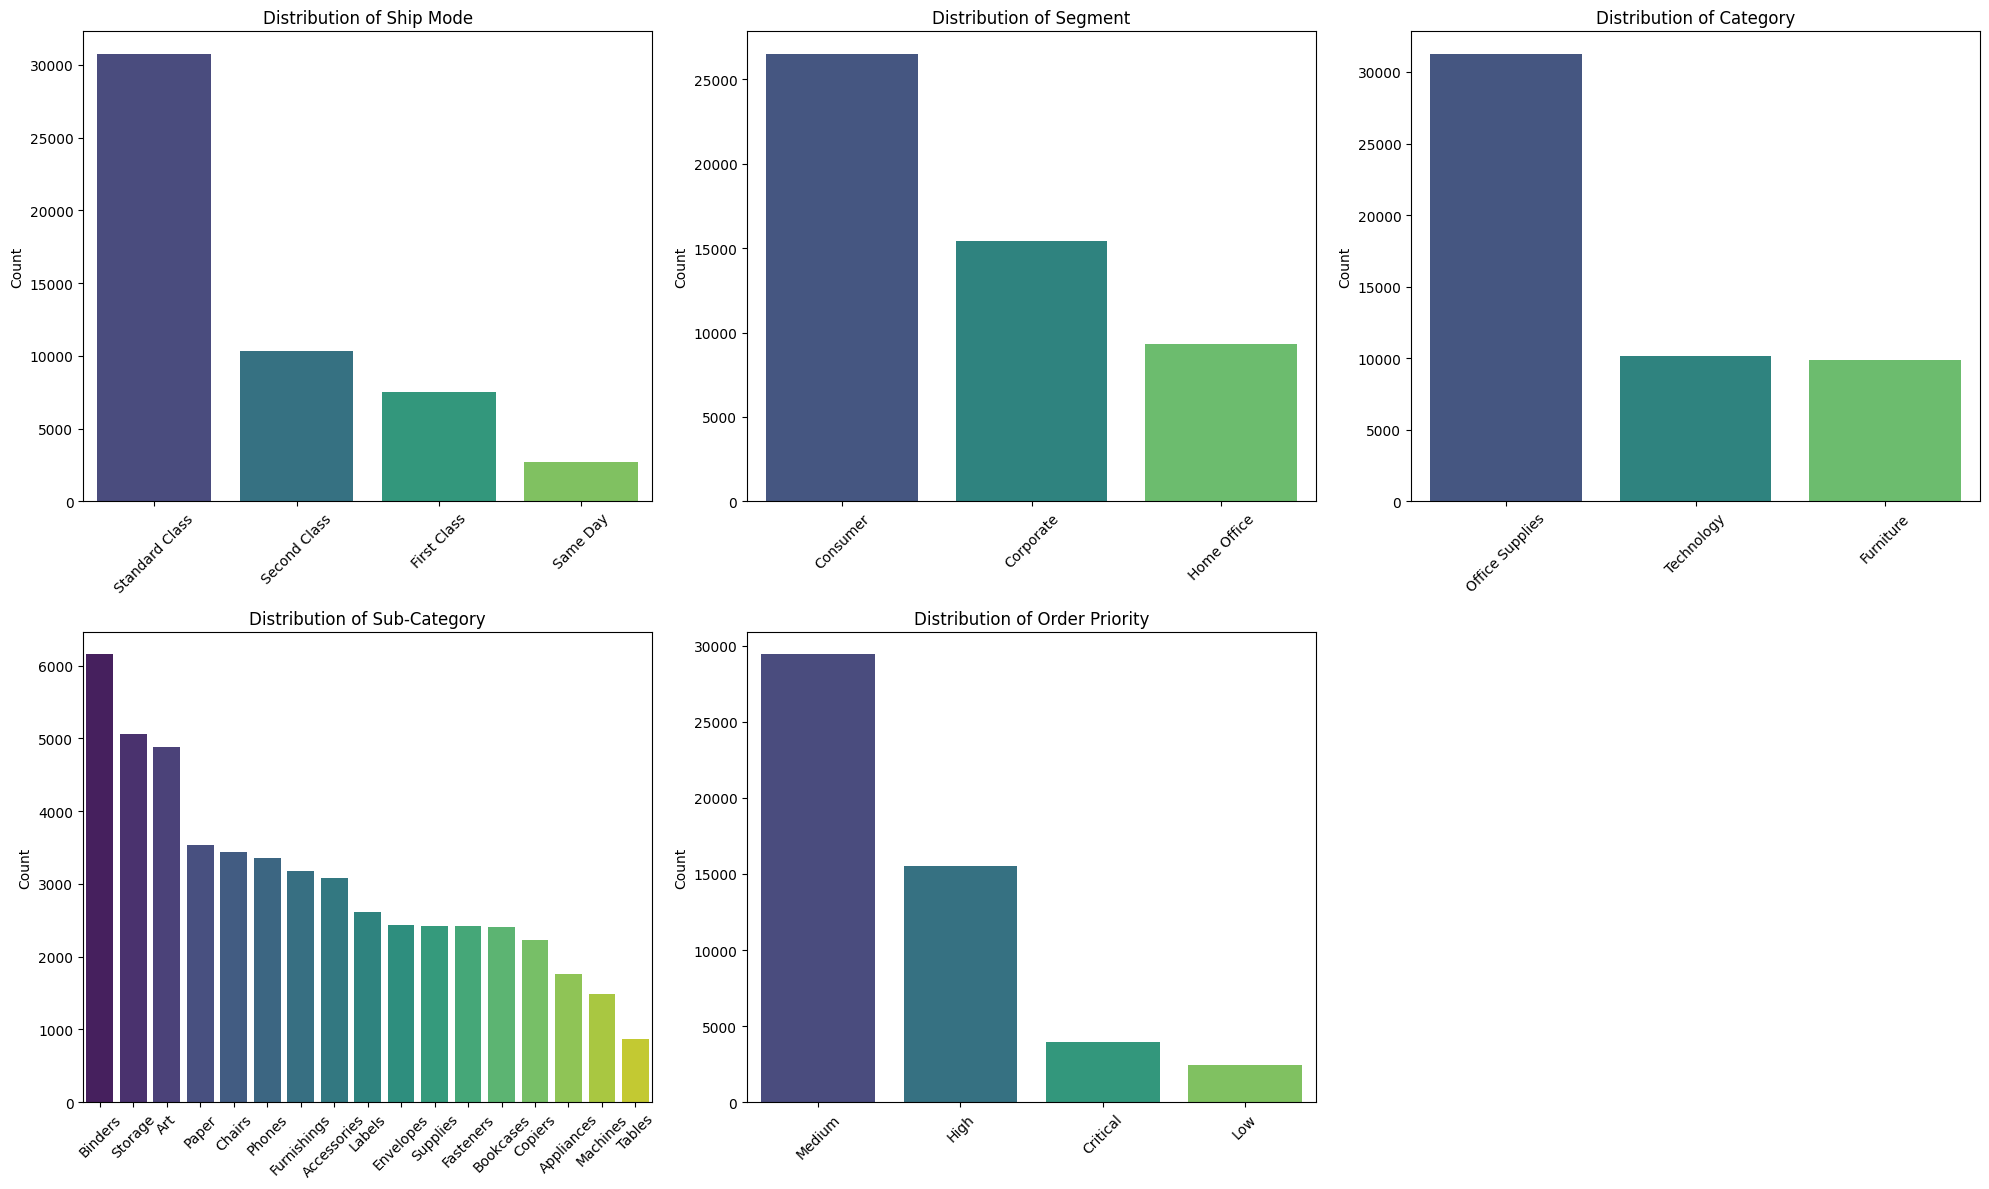

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

categorical_cols = ['Ship Mode', 'Segment', 'Category', 'Sub-Category', 'Order Priority']

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', order = df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('') # Remove x-axis label for cleaner look
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Observations from Categorical Feature Distributions:

*   **Ship Mode:** The majority of orders are shipped using 'Standard Class', followed by 'Second Class', 'First Class', and 'Same Day'. This indicates that customers generally prefer or opt for less expedited shipping.
*   **Segment:** The 'Consumer' segment accounts for the largest portion of the customer base, followed by 'Corporate' and 'Home Office'. This suggests that marketing efforts might be most effective when targeted towards consumers.
*   **Category:** 'Office Supplies' is the most frequently purchased category, significantly outnumbering 'Technology' and 'Furniture'. This could imply a higher volume of small-ticket items in office supplies.
*   **Sub-Category:** Within 'Office Supplies', 'Binders' and 'Paper' are the most popular sub-categories. For 'Technology', 'Phones' and 'Accessories' lead. In 'Furniture', 'Chairs' and 'Tables' are common. This level of detail can inform inventory management and promotional strategies.
*   **Order Priority:** 'Medium' priority orders are the most common, followed by 'High', 'Critical', and 'Low'. This distribution indicates that most orders are placed with a moderate level of urgency, with fewer urgent or non-urgent requests.

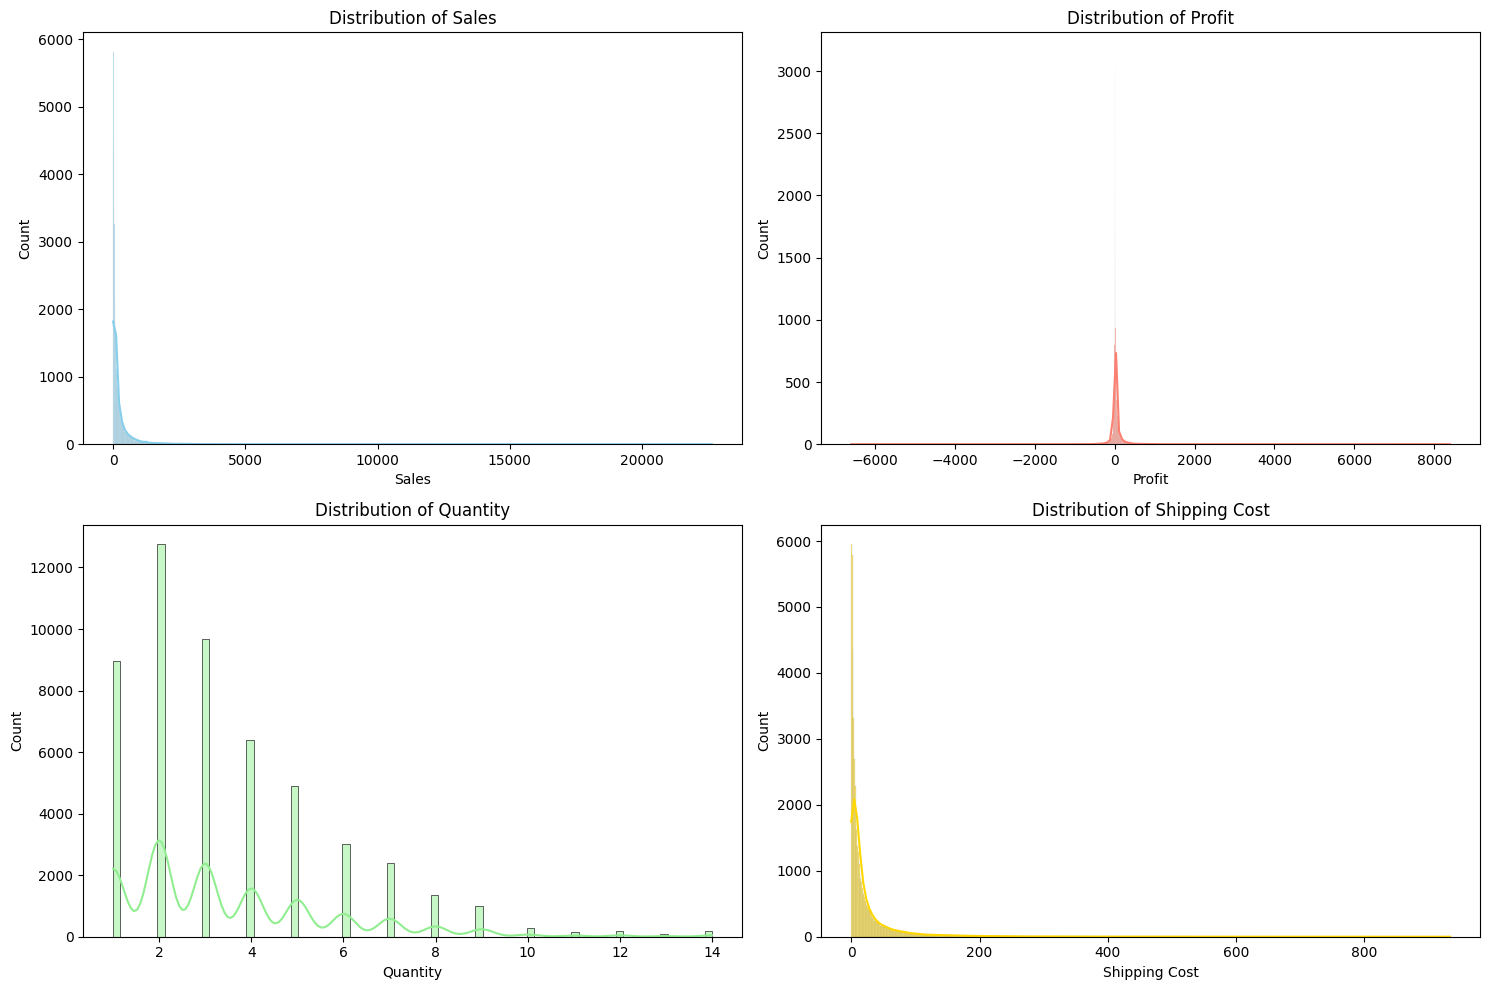

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(df['Sales'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Sales')

sns.histplot(df['Profit'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of Profit')

sns.histplot(df['Quantity'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Quantity')

sns.histplot(df['Shipping Cost'], kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Distribution of Shipping Cost')

plt.tight_layout()
plt.show()

### Observations from Numerical Feature Distributions:

*   **Sales:** The distribution of sales is highly right-skewed, indicating that most sales transactions are small, with a few large transactions. This is a common pattern in retail data.
*   **Profit:** The profit distribution is also right-skewed, but it's important to note the presence of negative profit values, suggesting that some transactions result in losses. This highlights areas for potential investigation into unprofitable sales.
*   **Quantity:** The quantity sold per transaction appears to be concentrated at lower values, likely 2-4 units, with decreasing frequency as the quantity increases. This indicates that customers generally purchase a small number of items per order.
*   **Shipping Cost:** Similar to sales, shipping costs are also right-skewed, with most orders incurring lower shipping costs and fewer orders having higher shipping expenses. This could correlate with the size or distance of the shipment.

In [15]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop('Postal Code', axis=1)

In [14]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [12]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [9]:
df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
count,51290.00000,51290,51290,51290,51290,51290,51290,51290,51290,51290,...,51290,51290,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290
unique,NaN,25035,1430,1464,4,1590,795,3,3636,1094,...,10292,3,17,3788,NaN,NaN,NaN,NaN,NaN,4
top,NaN,CA-2014-100111,18-06-2014,22-11-2014,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,...,OFF-AR-10003651,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,14,135,130,30775,97,108,26518,915,2001,...,35,31273,6152,227,NaN,NaN,NaN,NaN,NaN,29433
mean,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,246.490581,3.476545,0.142908,28.610982,26.375915,NaN
std,14806.29199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,487.565361,2.278766,0.212280,174.340972,57.296804,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,0.000000,NaN
25%,12823.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,30.758625,2.000000,0.000000,0.000000,2.610000,NaN
50%,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,85.053000,3.000000,0.000000,9.240000,7.790000,NaN
75%,38467.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,251.053200,5.000000,0.200000,36.810000,24.450000,NaN
